### Using addWeighted function

Formula : new_pixel = alpha x pixel_1 + beta x pixel_2 + gamma

In [1]:
import cv2

In [2]:
img1 = cv2.imread(r'Computer-Vision-with-Python\DATA\dog_backpack.jpg')
img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2 = cv2.imread(r'Computer-Vision-with-Python\DATA\watermark_no_copy.png')
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)


In [4]:
import matplotlib.pyplot as plt

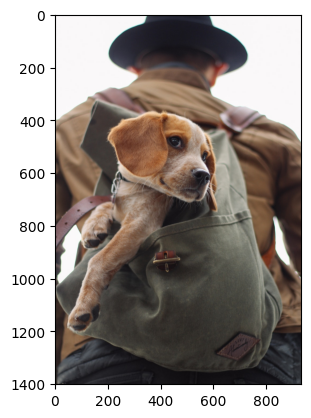

In [5]:
plt.imshow(img1)

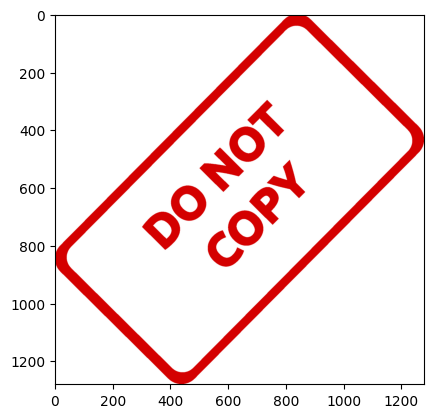

In [6]:
plt.imshow(img2)

## Blending images of same Size

In [7]:
img1 = cv2.resize(img1,(1200,1200))
img2 = cv2.resize(img2,(1200,1200))

(-0.5, 1199.5, 1199.5, -0.5)

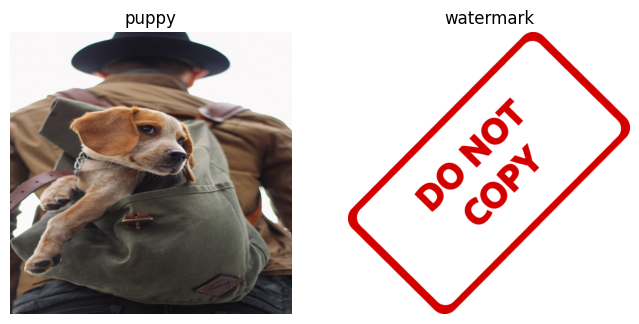

In [15]:
plt.figure(figsize=(8,6))
plt.subplot(121)
plt.imshow(img1)
plt.title('puppy')
plt.axis('off')

#plt.figure(figsize=(8,6))
plt.subplot(122)
plt.imshow(img2)
plt.title('watermark')
plt.axis('off')

In [16]:
blended = cv2.addWeighted(src1=img1, alpha=0.5, src2=img2, beta=0.5, gamma=0)

In [19]:
type(blended)

numpy.ndarray

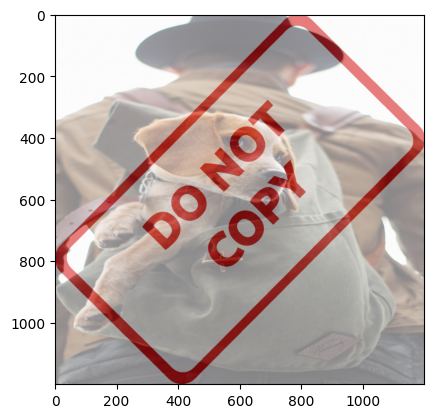

In [21]:
plt.imshow(blended)

In [22]:
blended2 = cv2.addWeighted(src1=img1, alpha=0.8, src2=img2, beta=0.1, gamma=0)

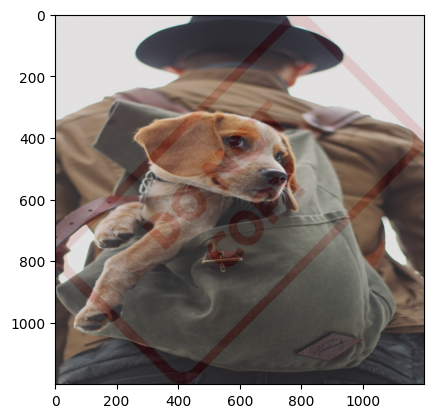

In [24]:
plt.imshow(blended2)

## Overlaying images with different sizes

A small image on top  of a large image with no blending

A numpy reassignment operation

In [25]:
img1 = cv2.imread(r'Computer-Vision-with-Python\DATA\dog_backpack.jpg')
img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2 = cv2.imread(r'Computer-Vision-with-Python\DATA\watermark_no_copy.png')
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)


In [26]:
img2 = cv2.resize(img2,(600,600))

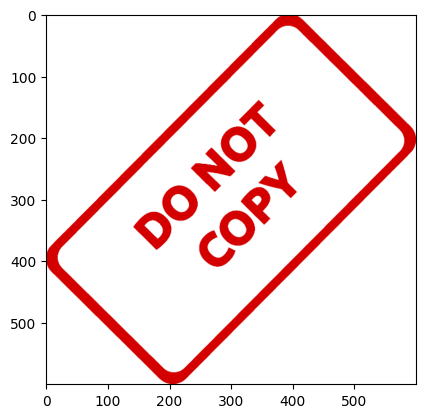

In [28]:
plt.imshow(img2)

In [29]:
large_img = img1
small_img = img2

In [30]:
x_offset = 0
y_offset = 0

In [31]:
x_end = x_offset + small_img.shape[1]
y_end = y_offset + small_img.shape[0]

In [34]:
large_img[y_offset:y_end,x_offset:x_end] = small_img

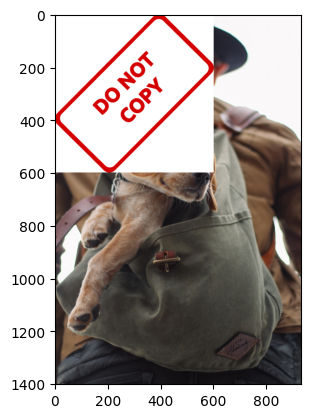

In [36]:
plt.imshow(large_img)

# Overlay with masking

In [37]:
img1 = cv2.imread(r'Computer-Vision-with-Python\DATA\dog_backpack.jpg')
img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2 = cv2.imread(r'Computer-Vision-with-Python\DATA\watermark_no_copy.png')
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)


In [38]:
img2 = cv2.resize(img2, (600,600))

Create a ROI : Region of Interest

In [39]:
img1.shape

(1401, 934, 3)

In [40]:
x_offset = 934-600
y_offset = 1401-600

In [41]:
rows, cols, channels = img2.shape

In [42]:
roi = img1[y_offset:1401, x_offset:943]

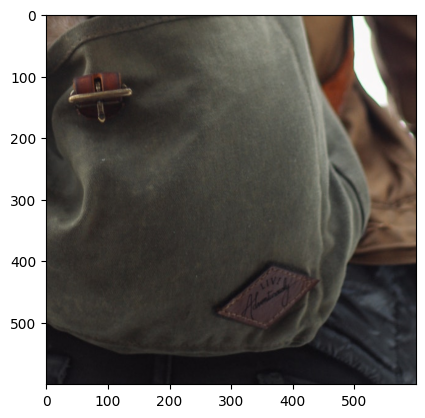

In [43]:
plt.imshow(roi)

In [44]:
img2gray = cv2.cvtColor(img2, cv2.COLOR_RGB2GRAY)

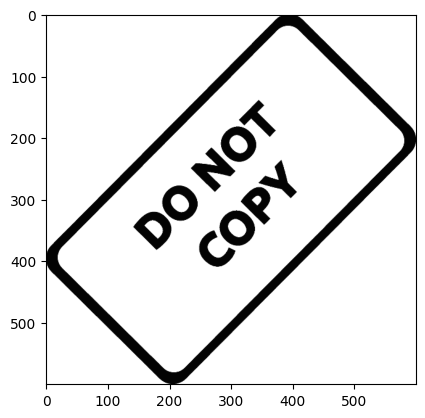

In [45]:
plt.imshow(img2gray, cmap='gray')

In [46]:
mask_inv = cv2.bitwise_not(img2gray)

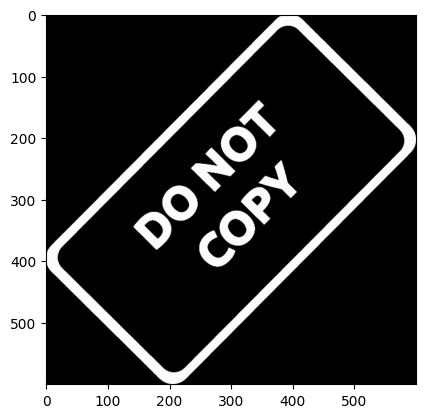

In [47]:
plt.imshow(mask_inv, cmap='gray')

In [48]:
mask_inv.shape

(600, 600)

In [49]:
import numpy as np

In [50]:
white_background = np.full(img2.shape, 255, dtype=np.uint8)

In [51]:
white_background.shape

(600, 600, 3)

In [52]:
bk = cv2.bitwise_or(white_background,white_background,mask=mask_inv)

In [53]:
bk.shape

(600, 600, 3)

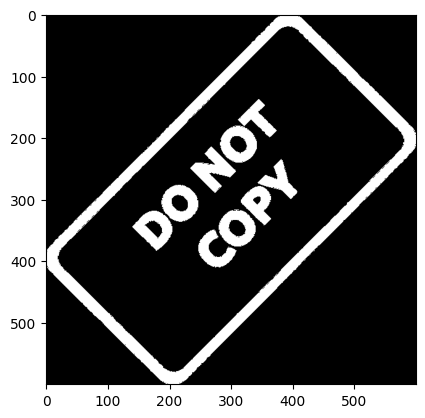

In [54]:
plt.imshow(bk)

In [55]:
fg = cv2.bitwise_or(img2,img2,mask=mask_inv)

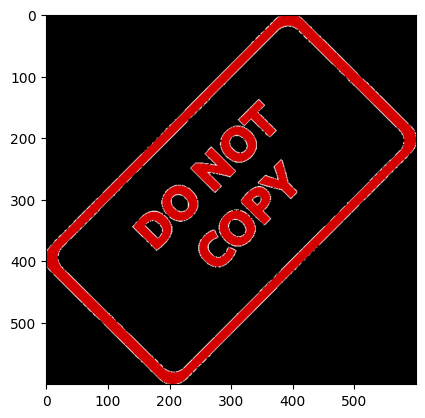

In [56]:
plt.imshow(fg)

In [57]:
final_roi = cv2.bitwise_or(roi,fg)

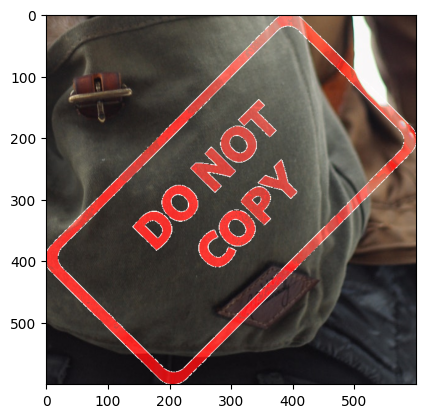

In [58]:
plt.imshow(final_roi)

In [59]:
large_img = img1
small_img = final_roi

In [62]:
large_img[y_offset:y_offset+small_img.shape[0], x_offset:x_offset+small_img.shape[1]]=small_img

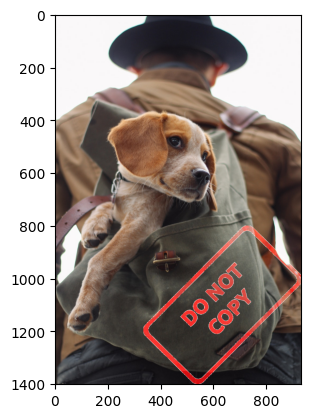

In [63]:
plt.imshow(large_img)